Initial dimensions: (89293, 22)

Initial columns:
['datetime', 'station', 'lat', 'lon', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'std_3*3_TB_4', 'std_3*3_TB_5', 'std_3*3_TB_6', 'std_3*3_TB_7', 'std_3*3_TB_8', 'std_3*3_TB_9', 'std_3*3_TB_10', 'std_3*3_TB_11', 'fls_station_cf', 'fls_station_hc']

Number of unique stations: 11

=== Checking for missing values ===
TB4        1
TB1_TB2    1
TB4_TB9    1
dtype: int64

Total number of missing values: 3
Dimensions after removing missing values: (89292, 27)

=== Statistics for new columns ===
            TB1_TB2       TB4_TB9      TB10_TB9       TB9_TB5      TB11_TB9
count  89292.000000  89292.000000  89292.000000  89292.000000  89292.000000
mean      47.167335      1.673775     -1.161361     45.493561    -21.944311
std       12.360528      6.641929      1.180763     12.753872      6.236436
min       -6.676560     -7.761093    -10.927063     -1.589508    -42.835785
25%       40.040431     -3.017757     -1.756561     40.471684  

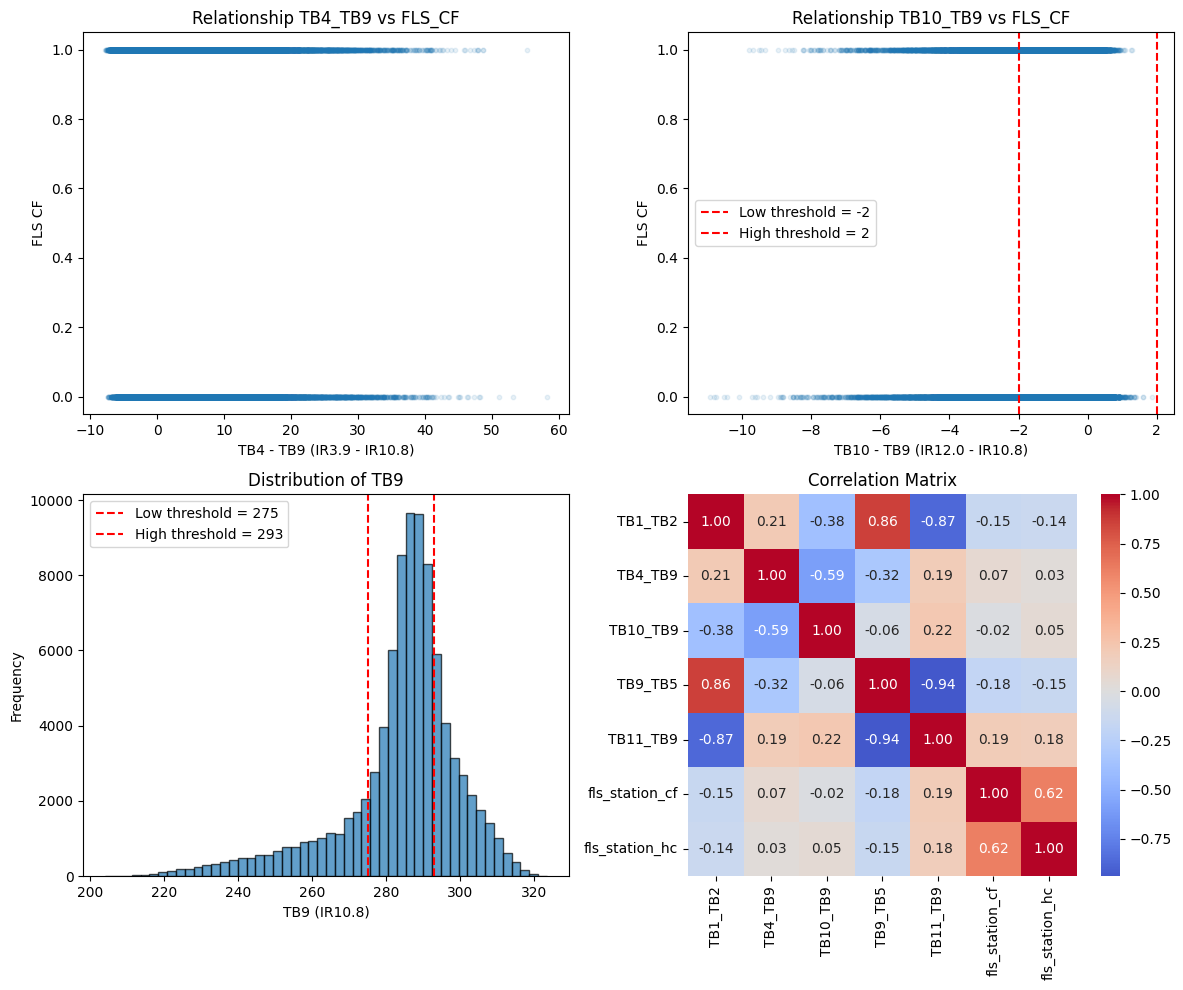


=== Final data structure ===
Total number of observations: 89292
Number of columns: 27

Available columns after preparation:
['datetime', 'station', 'lat', 'lon', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'std_3*3_TB_4', 'std_3*3_TB_5', 'std_3*3_TB_6', 'std_3*3_TB_7', 'std_3*3_TB_8', 'std_3*3_TB_9', 'std_3*3_TB_10', 'std_3*3_TB_11', 'fls_station_cf', 'fls_station_hc', 'TB1_TB2', 'TB4_TB9', 'TB10_TB9', 'TB9_TB5', 'TB11_TB9']

Prepared data saved to: C:\Users\moham\OneDrive\Documents\fog\data_ML_xgboost_prepared.csv

=== Sample of prepared data ===
    datetime         station   TB4_TB9  TB10_TB9         TB9  fls_station_cf  \
0 2024-01-01  AGADIR-MASSIRA -2.092075 -0.573975  279.538605             0.0   
1 2024-01-01      AL-HOCEIMA  2.737547 -0.907715  244.043213             0.0   
2 2024-01-01         KENITRA  4.423474 -1.302338  250.544006             1.0   
3 2024-01-01        LAAYOUNE -0.756197 -0.418213  279.832947             0.0   
4 2024-01-01       MARRAKECH -

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
file_path = Path(r"C:\Users\moham\OneDrive\Documents\fog\data_ML_xgboost (2).csv")
df = pd.read_csv(file_path, parse_dates=['datetime'])

print(f"Initial dimensions: {df.shape}")
print("\nInitial columns:")
print(df.columns.tolist())
print(f"\nNumber of unique stations: {df['station'].nunique()}")

# 2. Add brightness temperature differences
# Note: TB4 = IR3.9, TB9 = IR10.8, TB10 = IR12.0, etc.

# Specific requested differences
df['TB1_TB2'] = df['TB4'] - df['TB5']  # IR3.9 - IR8.7
df['TB4_TB9'] = df['TB4'] - df['TB9']  # IR3.9 - IR10.8

# Other important differences for FLS detection (based on literature)
df['TB10_TB9'] = df['TB10'] - df['TB9']    # IR12.0 - IR10.8 (for optical thickness)
df['TB9_TB5'] = df['TB9'] - df['TB5']      # IR10.8 - IR8.7
df['TB11_TB9'] = df['TB11'] - df['TB9']    # IR13.4 - IR10.8

# 3. Check and handle missing values
print("\n=== Checking for missing values ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if df.isnull().any().any():
    print(f"\nTotal number of missing values: {df.isnull().sum().sum()}")
    # Remove rows with missing values (or use another strategy)
    df = df.dropna()
    print(f"Dimensions after removing missing values: {df.shape}")

# 4. Statistical analysis of new columns
print("\n=== Statistics for new columns ===")
# Removed TB9_TB4 from the list
new_columns = ['TB1_TB2', 'TB4_TB9', 'TB10_TB9', 'TB9_TB5', 'TB11_TB9']
print(df[new_columns].describe())

# 5. Distribution of target variables
print("\n=== Distribution of target variables ===")
print("CF Configuration (Low Constraints):")
print(df['fls_station_cf'].value_counts(normalize=True))
print("\nHC Configuration (High Constraints):")
print(df['fls_station_hc'].value_counts(normalize=True))

# 6. Visualization of key relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Relationship between TB4_TB9 (the inverse) and FLS_CF
# Updated to use TB4_TB9 as TB9_TB4 was removed
axes[0, 0].scatter(df['TB4_TB9'], df['fls_station_cf'], alpha=0.1, s=10)
axes[0, 0].set_xlabel('TB4 - TB9 (IR3.9 - IR10.8)')
axes[0, 0].set_ylabel('FLS CF')
axes[0, 0].set_title('Relationship TB4_TB9 vs FLS_CF')

# Relationship between TB10_TB9 and FLS_CF
axes[0, 1].scatter(df['TB10_TB9'], df['fls_station_cf'], alpha=0.1, s=10)
axes[0, 1].axvline(x=-2, color='r', linestyle='--', label='Low threshold = -2')
axes[0, 1].axvline(x=2, color='r', linestyle='--', label='High threshold = 2')
axes[0, 1].set_xlabel('TB10 - TB9 (IR12.0 - IR10.8)')
axes[0, 1].set_ylabel('FLS CF')
axes[0, 1].set_title('Relationship TB10_TB9 vs FLS_CF')
axes[0, 1].legend()

# Distribution of TB9
axes[1, 0].hist(df['TB9'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=275, color='r', linestyle='--', label='Low threshold = 275')
axes[1, 0].axvline(x=293, color='r', linestyle='--', label='High threshold = 293')
axes[1, 0].set_xlabel('TB9 (IR10.8)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of TB9')
axes[1, 0].legend()

# Correlation matrix of new variables
corr_matrix = df[new_columns + ['fls_station_cf', 'fls_station_hc']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# 7. Final data structure
print("\n=== Final data structure ===")

print(f"Total number of observations: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("\nAvailable columns after preparation:")
print(df.columns.tolist())

# 8. Export prepared DataFrame (optional)
output_path = file_path.parent / "data_ML_xgboost_prepared.csv"
df.to_csv(output_path, index=False)
print(f"\nPrepared data saved to: {output_path}")

# 9. Display a sample of prepared data
print("\n=== Sample of prepared data ===")
# Removed TB9_TB4 from sample view
sample_columns = ['datetime', 'station', 'TB4_TB9', 'TB10_TB9', 'TB9', 
                  'fls_station_cf', 'fls_station_hc']
print(df[sample_columns].head(10))

In [4]:
# Import necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

In [5]:
# Base features - these are the individual brightness temperatures
base_features = ['TB4', 'TB5', 'TB9', 'TB10', 'TB11']
print("Base features (individual TB):")
for f in base_features:
    print(f"  - {f}")

# Derived features - these are the differences between channels
# Note: TB9_TB4 has been removed as the inverse (TB4_TB9) is already present
derived_features = ['TB1_TB2', 'TB4_TB9', 'TB10_TB9', 'TB9_TB5', 'TB11_TB9']
print("\nDerived features (differences):")
for f in derived_features:
    print(f"  - {f}")

# Statistical features - these are the local standard deviations
std_features = [col for col in df.columns if 'std_3' in col]
print("\nStatistical features (local standard deviations):")
for f in std_features:
    print(f"  - {f}")

# Combine all features
features = base_features + derived_features + std_features
print(f"\nTotal number of features: {len(features)}")

Base features (individual TB):
  - TB4
  - TB5
  - TB9
  - TB10
  - TB11

Derived features (differences):
  - TB1_TB2
  - TB4_TB9
  - TB10_TB9
  - TB9_TB5
  - TB11_TB9

Statistical features (local standard deviations):
  - std_3*3_TB_4
  - std_3*3_TB_5
  - std_3*3_TB_6
  - std_3*3_TB_7
  - std_3*3_TB_8
  - std_3*3_TB_9
  - std_3*3_TB_10
  - std_3*3_TB_11

Total number of features: 18


In [6]:
# Separate predictive variables (X) and target variables (y)
X = df[features]  # All our features
y_cf = df['fls_station_cf']  # Target variable for Low Constraints (CF)
y_hc = df['fls_station_hc']  # Target variable for High Constraints (HC)

print(f"Dimensions of X: {X.shape}")
print(f"  - Number of observations: {X.shape[0]}")
print(f"  - Number of features: {X.shape[1]}")
print(f"\nClass distribution:")
print(f"  - FLS_CF = 1: {y_cf.mean():.3%} ({y_cf.sum()} events out of {len(y_cf)})")
print(f"  - FLS_HC = 1: {y_hc.mean():.3%} ({y_hc.sum()} events out of {len(y_hc)})")

Dimensions of X: (89292, 18)
  - Number of observations: 89292
  - Number of features: 18

Class distribution:
  - FLS_CF = 1: 39.833% (35568.0 events out of 89292)
  - FLS_HC = 1: 20.343% (18165.0 events out of 89292)


In [7]:
# Scaling is important so that all features have the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardizes the data (mean=0, standard deviation=1)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Normalization completed:")
print("  - Mean after normalization:", X_scaled_df.mean().mean())
print("  - Standard deviation after normalization:", X_scaled_df.std().mean())
print("\nPreview of normalized data:")
print(X_scaled_df.head())

Normalization completed:
  - Mean after normalization: -7.045056317769512e-17
  - Standard deviation after normalization: 1.0000055996528217

Preview of normalized data:
        TB4       TB5       TB9      TB10      TB11   TB1_TB2   TB4_TB9  \
0 -0.571591 -0.235823 -0.285187 -0.246453 -0.041404 -0.556356 -0.566984   
1 -2.672147 -1.456589 -2.496013 -2.458785 -2.487066 -2.422598  0.160161   
2 -2.111370 -1.310419 -2.091112 -2.081749 -2.046400 -1.833870  0.413993   
3 -0.459924 -0.731977 -0.266854 -0.218661  0.015007 -0.174628 -0.365855   
4 -0.557229 -0.662877 -0.266854 -0.209420 -0.064049 -0.324351 -0.579733   

   TB10_TB9   TB9_TB5  TB11_TB9  std_3*3_TB_4  std_3*3_TB_5  std_3*3_TB_6  \
0  0.497467 -0.243924  0.664264     -0.605753     -0.408407     -0.508431   
1  0.214817 -2.431290  2.225089      1.242734     -0.072855      0.377676   
2 -0.119395 -1.992910  1.926996     -0.227575      0.230867     -0.165845   
3  0.629384  0.021287  0.712347     -0.495153     -0.547140     -0.3546

In [8]:
# For CF (Low Constraints)
X_train_cf, X_test_cf, y_train_cf, y_test_cf = train_test_split(
    X_scaled_df,  # Normalized data
    y_cf,         # Target variable CF
    test_size=0.2,        # 20% for testing
    stratify=y_cf,        # Maintains FLS proportion in train and test
    random_state=42       # For reproducibility
)

# For HC (High Constraints)
X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X_scaled_df,  # Normalized data
    y_hc,         # Target variable HC
    test_size=0.2,        # 20% for testing
    stratify=y_hc,        # Maintains FLS proportion in train and test
    random_state=42       # For reproducibility
)

print("Set sizes for CF:")
print(f"  - Training: {len(X_train_cf)} observations")
print(f"  - Test: {len(X_test_cf)} observations")
print(f"\nSet sizes for HC:")
print(f"  - Training: {len(X_train_hc)} observations")
print(f"  - Test: {len(X_test_hc)} observations")

Set sizes for CF:
  - Training: 71433 observations
  - Test: 17859 observations

Set sizes for HC:
  - Training: 71433 observations
  - Test: 17859 observations


In [9]:
def calculate_weather_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Calculates meteorology-specific metrics
    from predictions and ground truth values
    
    Parameters:
    ------------
    y_true : ground truth (actual values)
    y_pred : model predictions
    y_pred_proba : prediction probabilities (optional)
    
    Returns:
    ----------
    Dictionary containing all metrics
    """
    # Calculate the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Standard metrics
    accuracy = accuracy_score(y_true, y_pred)  # Overall accuracy
    precision = precision_score(y_true, y_pred, zero_division=0)  # Precision
    recall = recall_score(y_true, y_pred, zero_division=0)  # Recall
    
    # Meteorological metrics
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0  # Probability Of Detection
    far = fp / (tp + fp) if (tp + fp) > 0 else 0  # False Alarm Ratio
    fbias = (tp + fp) / (tp + fn) if (tp + fn) > 0 else 0  # Frequency Bias
    
    # Heidke Skill Score (HSS) - measures improvement over random chance
    total = tn + fp + fn + tp
    expected_correct = ((tp + fn)*(tp + fp) + (tn + fn)*(tn + fp)) / total
    hss = (tp + tn - expected_correct) / (total - expected_correct) if (total - expected_correct) > 0 else 0
    
    # ROC-AUC if probabilities are provided
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
    else:
        roc_auc = None
    
    # Compile results
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'POD': pod,
        'FAR': far,
        'FBIAS': fbias,
        'HSS': hss,
        'ROC-AUC': roc_auc,
        'Confusion_Matrix': [[tn, fp], [fn, tp]]
    }
    
    return metrics

# Test the function with a simple example
print("Example metrics calculation:")
sample_true = [0, 1, 0, 1, 0, 1]
sample_pred = [0, 1, 0, 0, 0, 1]
sample_metrics = calculate_weather_metrics(sample_true, sample_pred)

# Display metrics with appropriate formatting
for key, value in sample_metrics.items():
    if key != 'Confusion_Matrix':
        if value is None:
            print(f"  {key}: Not available")
        else:
            print(f"  {key}: {value:.3f}")

Example metrics calculation:
  Accuracy: 0.833
  Precision: 1.000
  Recall: 0.667
  F1-Score: 0.800
  POD: 0.667
  FAR: 0.000
  FBIAS: 0.667
  HSS: 0.667
  ROC-AUC: Not available


In [10]:
print("="*60)
print("MODEL TRAINING - CF CONFIGURATION")
print("="*60)

# XGBoost model configuration for CF (Low Constraints)
model_cf = xgb.XGBClassifier(
    objective='binary:logistic',  # Binary classification
    eval_metric='logloss',         # Evaluation metric
    use_label_encoder=False,       # Avoid using the label encoder
    random_state=42,               # For reproducibility
    # Weighting to handle class imbalance
    scale_pos_weight=len(y_train_cf[y_train_cf==0]) / len(y_train_cf[y_train_cf==1])
)

print("Initial CF model configuration:")
print(f"  - Objective: {model_cf.objective}")
print(f"  - Positive class weight: {model_cf.scale_pos_weight:.2f}")

# Hyperparameter grid definition
param_grid = {
    'max_depth': [3, 5, 7],           # Maximum tree depth
    'learning_rate': [0.01, 0.05, 0.1], # Learning rate
    'n_estimators': [100, 200],       # Number of trees
    'subsample': [0.8, 1.0],          # Percentage of samples used per tree
    'colsample_bytree': [0.8, 1.0]    # Percentage of features used per tree
}

print("\nHyperparameter grid to test:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

# Cross-validation configuration
cv = StratifiedKFold(
    n_splits=3,         # 3 folds for cross-validation
    shuffle=True,       # Shuffle the data
    random_state=42     # For reproducibility
)

print(f"\nCross-validation: {cv.n_splits} folds")

# Grid search configuration
grid_search_cf = GridSearchCV(
    estimator=model_cf,      # Model to optimize
    param_grid=param_grid,   # Hyperparameter grid
    cv=cv,                   # Cross-validation strategy
    scoring='roc_auc',       # Metric to optimize (ROC-AUC)
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

MODEL TRAINING - CF CONFIGURATION
Initial CF model configuration:
  - Objective: binary:logistic
  - Positive class weight: 1.51

Hyperparameter grid to test:
  - max_depth: [3, 5, 7]
  - learning_rate: [0.01, 0.05, 0.1]
  - n_estimators: [100, 200]
  - subsample: [0.8, 1.0]
  - colsample_bytree: [0.8, 1.0]

Cross-validation: 3 folds


In [11]:
print("Starting hyperparameter search for CF...")
print("This operation may take a few minutes...")

# Launch the hyperparameter search
grid_search_cf.fit(X_train_cf, y_train_cf)

print("\nSearch completed!")
print(f"Best CF hyperparameters: {grid_search_cf.best_params_}")
print(f"Best ROC-AUC score (cross-validation): {grid_search_cf.best_score_:.4f}")

# Retrieve the best model
best_model_cf = grid_search_cf.best_estimator_
print(f"\nBest CF model saved in 'best_model_cf'")

Starting hyperparameter search for CF...
This operation may take a few minutes...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Search completed!
Best CF hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC score (cross-validation): 0.7814

Best CF model saved in 'best_model_cf'


In [12]:
print("="*60)
print("MODEL TRAINING - HC CONFIGURATION")
print("="*60)

# XGBoost model configuration for HC (same logic as CF)
model_hc = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    # Note: weighting is different because classes differ for HC
    scale_pos_weight=len(y_train_hc[y_train_hc==0]) / len(y_train_hc[y_train_hc==1])
)

print("Initial HC model configuration:")
print(f"  - Objective: {model_hc.objective}")
print(f"  - Positive class weight: {model_hc.scale_pos_weight:.2f}")

# Using the same hyperparameter grid
print("\nUsing the same hyperparameter grid as CF")

# Grid search configuration for HC
grid_search_hc = GridSearchCV(
    estimator=model_hc,
    param_grid=param_grid,  # Same grid
    cv=cv,                  # Same cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

MODEL TRAINING - HC CONFIGURATION
Initial HC model configuration:
  - Objective: binary:logistic
  - Positive class weight: 3.92

Using the same hyperparameter grid as CF


In [13]:
print("Starting hyperparameter search for HC...")
print("This operation may take a few minutes...")

# Launch the hyperparameter search
grid_search_hc.fit(X_train_hc, y_train_hc)

print("\nSearch completed!")
print(f"Best HC hyperparameters: {grid_search_hc.best_params_}")
print(f"Best ROC-AUC score (cross-validation): {grid_search_hc.best_score_:.4f}")

# Retrieve the best model
best_model_hc = grid_search_hc.best_estimator_
print(f"\nBest HC model saved in 'best_model_hc'")

Starting hyperparameter search for HC...
This operation may take a few minutes...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Search completed!
Best HC hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC score (cross-validation): 0.8141

Best HC model saved in 'best_model_hc'


In [14]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a model and displays detailed results
    """
    print(f"\n{'='*60}")
    print(f"EVALUATING MODEL: {model_name}")
    print(f"{'='*60}")
    
    # Make predictions
    y_pred = model.predict(X_test)  # Class predictions (0 or 1)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1
    
    # Calculate all metrics
    metrics = calculate_weather_metrics(y_test, y_pred, y_pred_proba)
    
    # Display results
    print("PERFORMANCE METRICS:")
    print("-" * 40)
    
    # Main metrics
    metric_names = {
        'Accuracy': 'Overall Accuracy',
        'Precision': 'Precision',
        'Recall': 'Recall',
        'F1-Score': 'F1 Score',
        'POD': 'Probability of Detection (POD)',
        'FAR': 'False Alarm Ratio (FAR)',
        'FBIAS': 'Frequency Bias (FBIAS)',
        'HSS': 'Heidke Skill Score (HSS)',
        'ROC-AUC': 'Area Under ROC Curve'
    }
    
    for metric, name in metric_names.items():
        value = metrics[metric]
        if value is not None:
            if metric in ['POD', 'FAR', 'FBIAS', 'HSS']:
                print(f"{name:35} : {value:.3f}")
            else:
                print(f"{name:35} : {value:.4f}")
        else:
            print(f"{name:35} : Not available")
    
    # Confusion matrix
    print(f"\nCONFUSION MATRIX:")
    cm = metrics['Confusion_Matrix']
    print(f"                    Predicted 0   Predicted 1")
    print(f"Actual 0 (Non-FLS)   TN={cm[0][0]:<10} FP={cm[0][1]}")
    print(f"Actual 1 (FLS)       FN={cm[1][0]:<10} TP={cm[1][1]}")
    
    # Detailed classification report
    print(f"\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['Non-FLS', 'FLS']))
    
    return metrics, y_pred, y_pred_proba

In [15]:
# Evaluate the CF model on the test set
print("TEST SET EVALUATION")
print("="*50)

metrics_cf, y_pred_cf, y_pred_proba_cf = evaluate_model(
    best_model_cf, 
    X_test_cf, 
    y_test_cf, 
    "CF (Low Constraints)"
)

TEST SET EVALUATION

EVALUATING MODEL: CF (Low Constraints)
PERFORMANCE METRICS:
----------------------------------------
Overall Accuracy                    : 0.7051
Precision                           : 0.6097
Recall                              : 0.7215
F1 Score                            : 0.6609
Probability of Detection (POD)      : 0.722
False Alarm Ratio (FAR)             : 0.390
Frequency Bias (FBIAS)              : 1.183
Heidke Skill Score (HSS)            : 0.403
Area Under ROC Curve                : 0.7889

CONFUSION MATRIX:
                    Predicted 0   Predicted 1
Actual 0 (Non-FLS)   TN=7459       FP=3286
Actual 1 (FLS)       FN=1981       TP=5133

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Non-FLS       0.79      0.69      0.74     10745
         FLS       0.61      0.72      0.66      7114

    accuracy                           0.71     17859
   macro avg       0.70      0.71      0.70     17859
weighted avg       0.72      0

In [16]:
# Evaluate the HC model on the test set
metrics_hc, y_pred_hc, y_pred_proba_hc = evaluate_model(
    best_model_hc, 
    X_test_hc, 
    y_test_hc, 
    "HC (High Constraints)"
)


EVALUATING MODEL: HC (High Constraints)
PERFORMANCE METRICS:
----------------------------------------
Overall Accuracy                    : 0.7463
Precision                           : 0.4269
Recall                              : 0.7214
F1 Score                            : 0.5364
Probability of Detection (POD)      : 0.721
False Alarm Ratio (FAR)             : 0.573
Frequency Bias (FBIAS)              : 1.690
Heidke Skill Score (HSS)            : 0.377
Area Under ROC Curve                : 0.8229

CONFUSION MATRIX:
                    Predicted 0   Predicted 1
Actual 0 (Non-FLS)   TN=10708      FP=3518
Actual 1 (FLS)       FN=1012       TP=2621

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Non-FLS       0.91      0.75      0.83     14226
         FLS       0.43      0.72      0.54      3633

    accuracy                           0.75     17859
   macro avg       0.67      0.74      0.68     17859
weighted avg       0.81      0.75      0.77     1

In [17]:
print("="*60)
print("COMPARISON OF THE TWO CONFIGURATIONS")
print("="*60)

# Create a DataFrame to compare metrics
comparison_data = []

# Metrics to compare
metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
                      'POD', 'FAR', 'FBIAS', 'HSS', 'ROC-AUC']

for metric in metrics_to_compare:
    cf_value = metrics_cf[metric]
    hc_value = metrics_hc[metric]
    
    comparison_data.append({
        'Metric': metric,
        'CF (Low Constraints)': cf_value if cf_value is not None else 'N/A',
        'HC (High Constraints)': hc_value if hc_value is not None else 'N/A',
        'Difference (HC - CF)': hc_value - cf_value if isinstance(cf_value, (int, float)) and isinstance(hc_value, (int, float)) else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("\nPerformance Comparison Table:")
print("-" * 80)

# Improved display format
for _, row in comparison_df.iterrows():
    metric = row['Metric']
    cf_val = row['CF (Low Constraints)']
    hc_val = row['HC (High Constraints)']
    diff = row['Difference (HC - CF)']
    
    if isinstance(cf_val, (int, float)) and isinstance(hc_val, (int, float)):
        print(f"{metric:15} | CF: {cf_val:7.4f} | HC: {hc_val:7.4f} | Δ: {diff:7.4f}")
    else:
        print(f"{metric:15} | CF: {cf_val:7} | HC: {hc_val:7} | Δ: {diff:7}")

print("-" * 80)

# Results Analysis
print("\nRESULTS ANALYSIS:")
print("-" * 40)

# Check which model is better according to different metrics
if metrics_hc['ROC-AUC'] > metrics_cf['ROC-AUC']:
    print(" The HC model has better discriminative capacity (higher ROC-AUC)")
else:
    print(" The CF model has better discriminative capacity (higher ROC-AUC)")

if metrics_hc['FAR'] < metrics_cf['FAR']:
    print(" The HC model has fewer false alarms (lower FAR)")
else:
    print(" The CF model has fewer false alarms (lower FAR)")

if metrics_hc['POD'] > metrics_cf['POD']:
    print(" The HC model detects FLS better (higher POD)")
else:
    print(" The CF model detects FLS better (higher POD)")

if abs(metrics_hc['FBIAS'] - 1) < abs(metrics_cf['FBIAS'] - 1):
    print(" The HC model has lower bias (FBIAS closer to 1)")
else:
    print(" The CF model has lower bias (FBIAS closer to 1)")

if metrics_hc['HSS'] > metrics_cf['HSS']:
    print(" The HC model has better overall performance (higher HSS)")
else:
    print(" The CF model has better overall performance (higher HSS)")

COMPARISON OF THE TWO CONFIGURATIONS

Performance Comparison Table:
--------------------------------------------------------------------------------
Accuracy        | CF:  0.7051 | HC:  0.7463 | Δ:  0.0413
Precision       | CF:  0.6097 | HC:  0.4269 | Δ: -0.1827
Recall          | CF:  0.7215 | HC:  0.7214 | Δ: -0.0001
F1-Score        | CF:  0.6609 | HC:  0.5364 | Δ: -0.1245
POD             | CF:  0.7215 | HC:  0.7214 | Δ: -0.0001
FAR             | CF:  0.3903 | HC:  0.5731 | Δ:  0.1827
FBIAS           | CF:  1.1834 | HC:  1.6898 | Δ:  0.5063
HSS             | CF:  0.4032 | HC:  0.3773 | Δ: -0.0260
ROC-AUC         | CF:  0.7889 | HC:  0.8229 | Δ:  0.0340
--------------------------------------------------------------------------------

RESULTS ANALYSIS:
----------------------------------------
 The HC model has better discriminative capacity (higher ROC-AUC)
 The CF model has fewer false alarms (lower FAR)
 The CF model detects FLS better (higher POD)
 The CF model has lower bias (FBIAS 

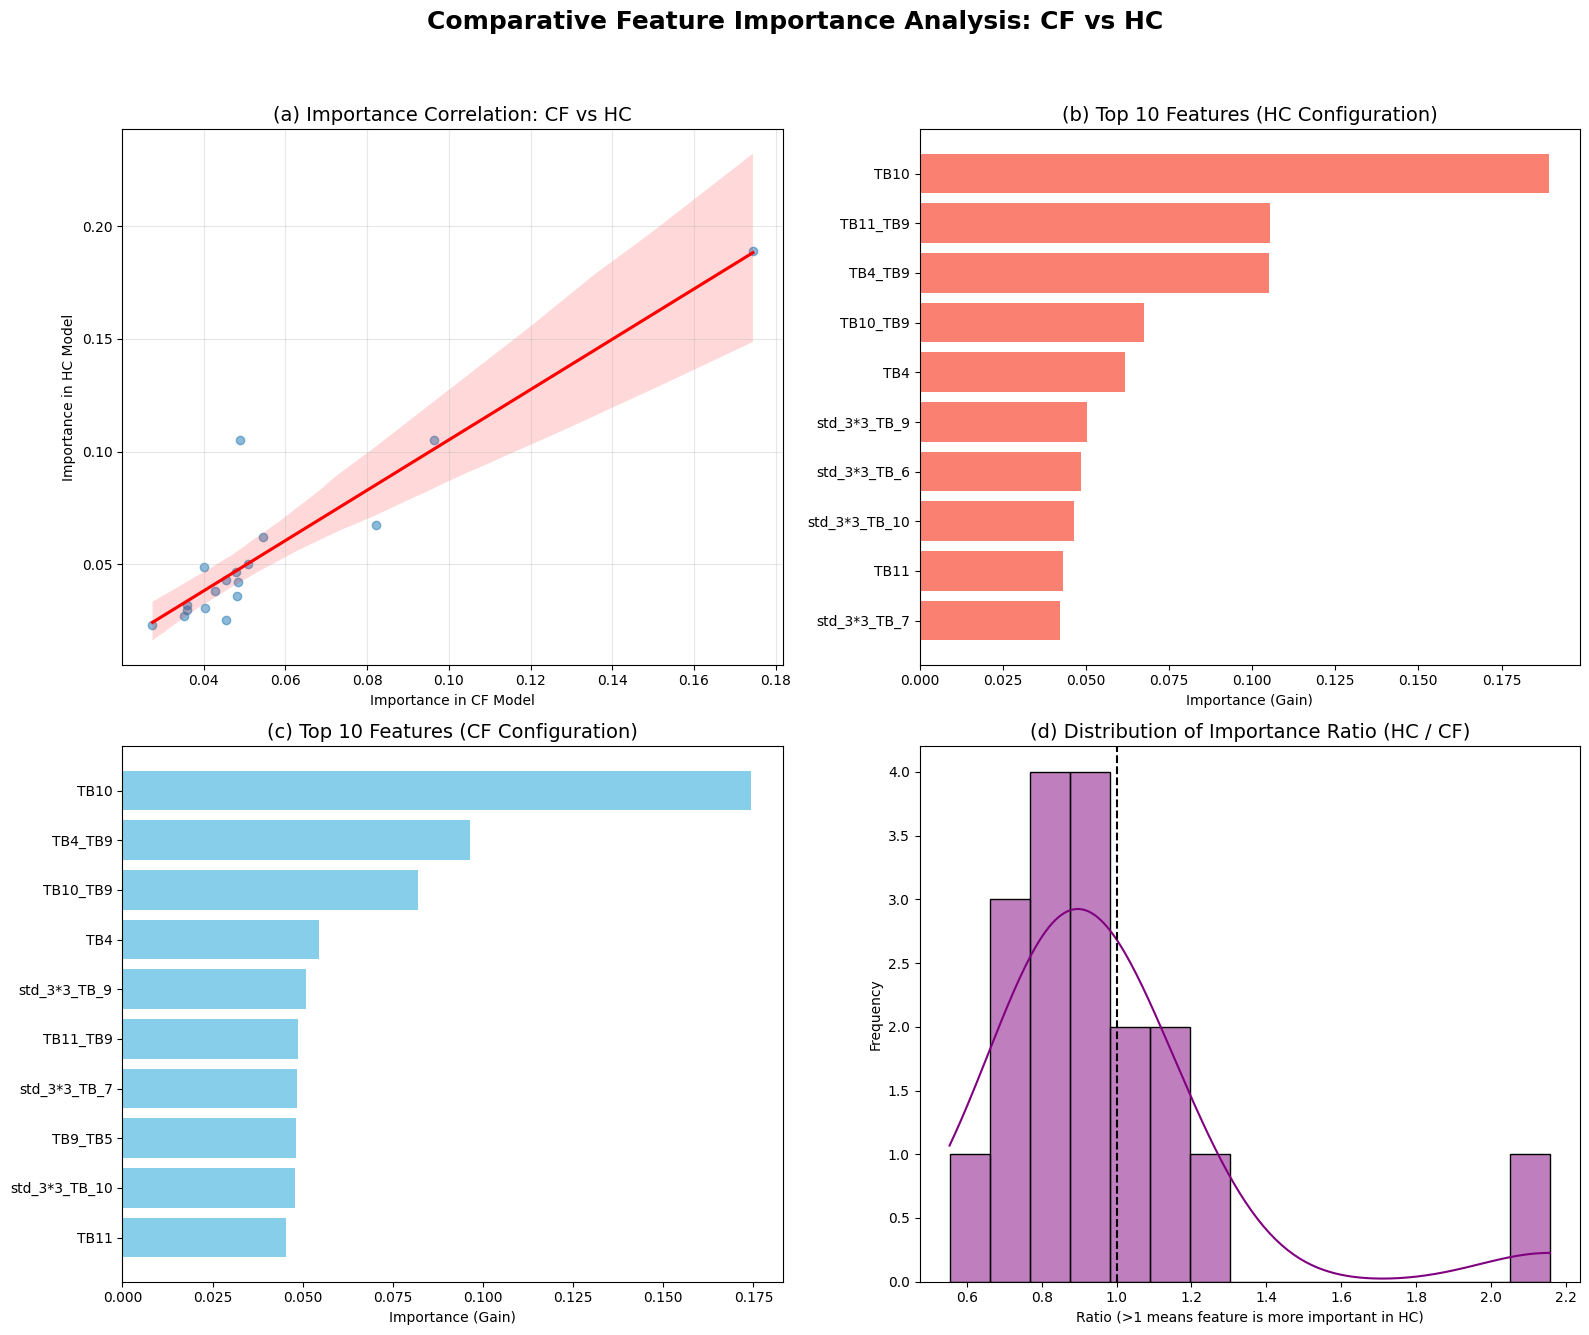


SUMMARY OF TOP FEATURES
Feature              | CF Importance   | HC Importance  
------------------------------------------------------------
TB10                 | 0.1745          | 0.1891
TB11_TB9             | 0.0488          | 0.1052
TB4_TB9              | 0.0964          | 0.1051
TB10_TB9             | 0.0821          | 0.0674
TB4                  | 0.0546          | 0.0619
std_3*3_TB_9         | 0.0509          | 0.0503
std_3*3_TB_6         | 0.0401          | 0.0485
std_3*3_TB_10        | 0.0478          | 0.0464
TB11                 | 0.0455          | 0.0430
std_3*3_TB_7         | 0.0484          | 0.0422


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_feature_comparison(model_cf, model_hc, features):
    """
    Generates a 2x2 dashboard focusing on:
    (a) Importance Correlation
    (b) Top 10 HC Features
    (c) Top 10 CF Features
    (d) HC/CF Ratio Distribution
    """
    # 1. Prepare Data
    imp_cf = pd.DataFrame({'Feature': features, 'Importance_CF': model_cf.feature_importances_})
    imp_hc = pd.DataFrame({'Feature': features, 'Importance_HC': model_hc.feature_importances_})
    
    # Merge for comparison
    df_comp = pd.merge(imp_cf, imp_hc, on='Feature')
    df_comp['Ratio_HC_CF'] = df_comp['Importance_HC'] / (df_comp['Importance_CF'] + 1e-9)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('Comparative Feature Importance Analysis: CF vs HC', fontsize=18, fontweight='bold')

    # (a) Correlation of Importances CF–HC
    sns.regplot(x='Importance_CF', y='Importance_HC', data=df_comp, ax=axes[0, 0], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[0, 0].set_title('(a) Importance Correlation: CF vs HC', fontsize=14)
    axes[0, 0].set_xlabel('Importance in CF Model')
    axes[0, 0].set_ylabel('Importance in HC Model')
    axes[0, 0].grid(True, alpha=0.3)

    # (b) Top 10 Features (HC)
    top_10_hc = df_comp.sort_values('Importance_HC', ascending=False).head(10)
    axes[0, 1].barh(top_10_hc['Feature'], top_10_hc['Importance_HC'], color='salmon')
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_title('(b) Top 10 Features (HC Configuration)', fontsize=14)
    axes[0, 1].set_xlabel('Importance (Gain)')

    # (c) Top 10 Features (CF)
    top_10_cf = df_comp.sort_values('Importance_CF', ascending=False).head(10)
    axes[1, 0].barh(top_10_cf['Feature'], top_10_cf['Importance_CF'], color='skyblue')
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_title('(c) Top 10 Features (CF Configuration)', fontsize=14)
    axes[1, 0].set_xlabel('Importance (Gain)')

    # (d) Distribution of HC/CF Ratio
    # We use log scale if ratios are very spread out, otherwise standard histogram
    sns.histplot(df_comp['Ratio_HC_CF'], bins=15, kde=True, ax=axes[1, 1], color='purple')
    axes[1, 1].axvline(x=1.0, color='black', linestyle='--')
    axes[1, 1].set_title('(d) Distribution of Importance Ratio (HC / CF)', fontsize=14)
    axes[1, 1].set_xlabel('Ratio (>1 means feature is more important in HC)')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Numerical Summary
    print("\nSUMMARY OF TOP FEATURES")
    print("="*60)
    print(f"{'Feature':<20} | {'CF Importance':<15} | {'HC Importance':<15}")
    print("-" * 60)
    for i in range(10):
        feat = top_10_hc.iloc[i]['Feature']
        val_cf = top_10_hc.iloc[i]['Importance_CF']
        val_hc = top_10_hc.iloc[i]['Importance_HC']
        print(f"{feat:<20} | {val_cf:.4f}          | {val_hc:.4f}")

# Execute the analysis
plot_final_feature_comparison(best_model_cf, best_model_hc, features)

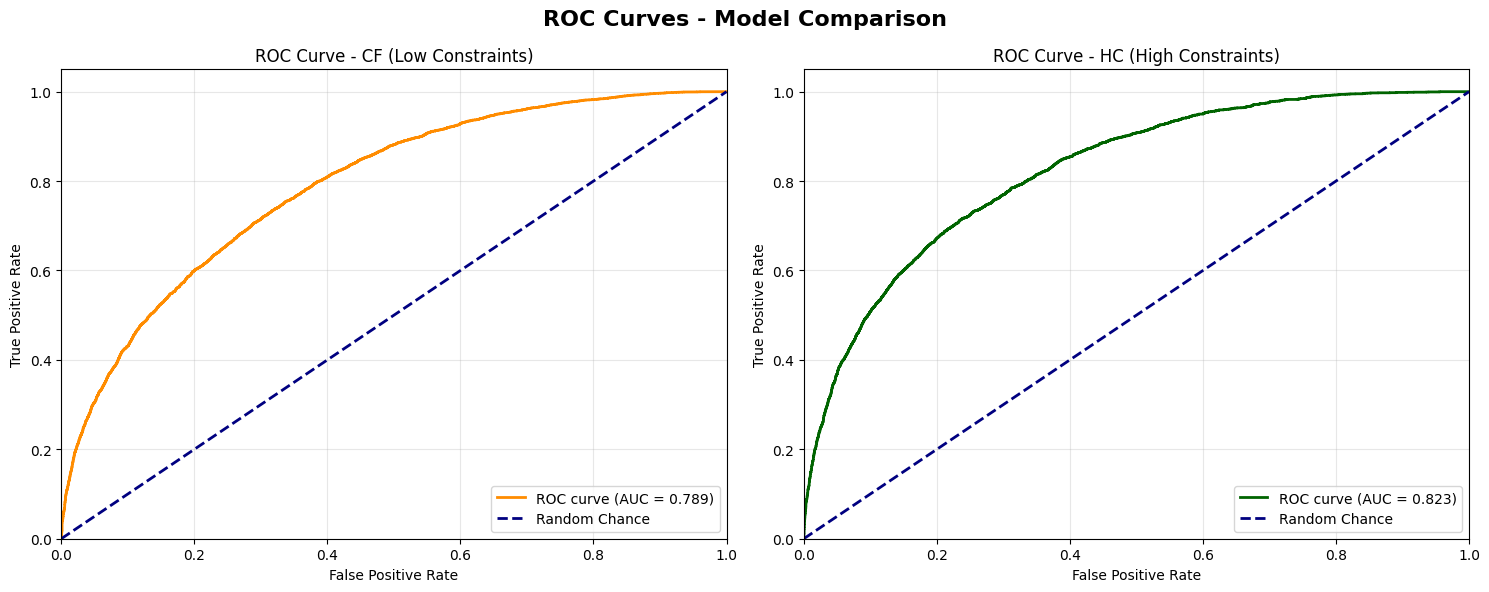

AUC-ROC CF: 0.7889
AUC-ROC HC: 0.8229
Difference (HC - CF): 0.0340


In [19]:
# Function to plot ROC curves
def plot_roc_curves(y_true_cf, y_pred_proba_cf, y_true_hc, y_pred_proba_hc, model_names):
    """
    Plots ROC curves for both models
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
    
    # ROC curve for CF (Low Constraints)
    fpr_cf, tpr_cf, _ = roc_curve(y_true_cf, y_pred_proba_cf)
    roc_auc_cf = auc(fpr_cf, tpr_cf)
    
    axes[0].plot(fpr_cf, tpr_cf, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc_cf:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve - {model_names[0]}')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    
    # ROC curve for HC (High Constraints)
    fpr_hc, tpr_hc, _ = roc_curve(y_true_hc, y_pred_proba_hc)
    roc_auc_hc = auc(fpr_hc, tpr_hc)
    
    axes[1].plot(fpr_hc, tpr_hc, color='darkgreen', lw=2, 
                label=f'ROC curve (AUC = {roc_auc_hc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {model_names[1]}')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return roc_auc_cf, roc_auc_hc

# Plot the ROC curves
roc_auc_cf, roc_auc_hc = plot_roc_curves(
    y_test_cf, y_pred_proba_cf,
    y_test_hc, y_pred_proba_hc,
    ['CF (Low Constraints)', 'HC (High Constraints)']
)

print(f"AUC-ROC CF: {roc_auc_cf:.4f}")
print(f"AUC-ROC HC: {roc_auc_hc:.4f}")
print(f"Difference (HC - CF): {roc_auc_hc - roc_auc_cf:.4f}")

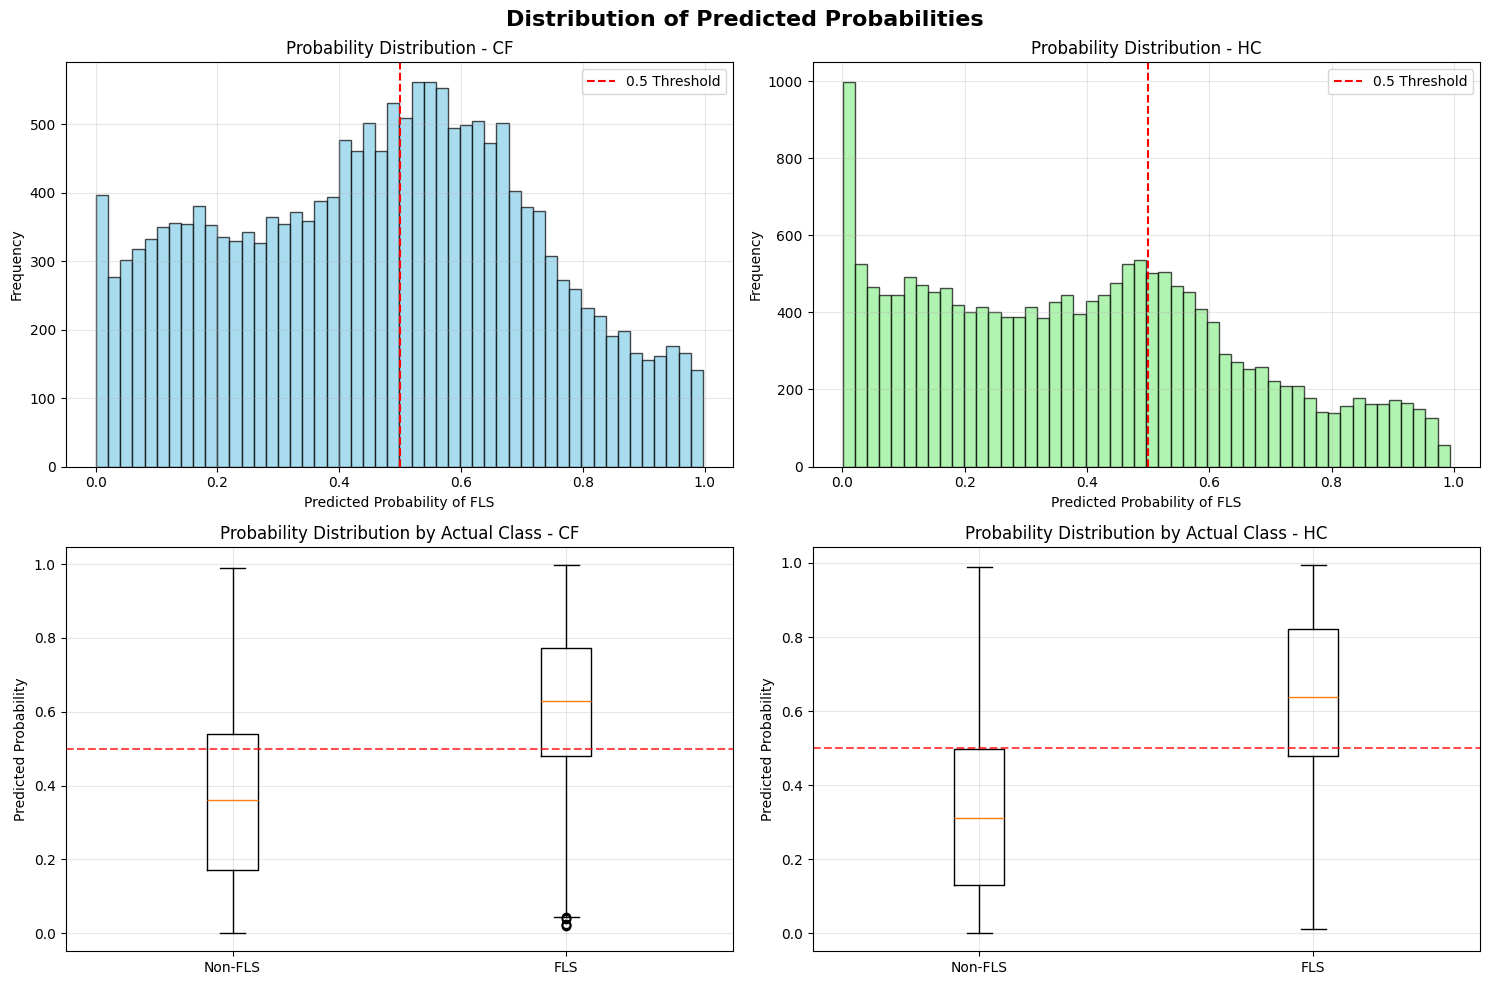

Statistics of Predicted Probabilities:
--------------------------------------------------
CF (Low Constraints):
  Mean: 0.4654
  Standard Deviation: 0.2509
  Median: 0.4808
  Min: 0.0006
  Max: 0.9965

HC (High Constraints):
  Mean: 0.3906
  Standard Deviation: 0.2571
  Median: 0.3823
  Min: 0.0009
  Max: 0.9932


In [20]:
# Distribution of predicted probabilities
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Predicted Probabilities', fontsize=16, fontweight='bold')

# CF - Probability Histogram
axes[0, 0].hist(y_pred_proba_cf, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Predicted Probability of FLS')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Probability Distribution - CF')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', label='0.5 Threshold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# HC - Probability Histogram
axes[0, 1].hist(y_pred_proba_hc, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Predicted Probability of FLS')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Probability Distribution - HC')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', label='0.5 Threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CF - Boxplot by Actual Class
boxplot_data_cf = [y_pred_proba_cf[y_test_cf == 0], y_pred_proba_cf[y_test_cf == 1]]
axes[1, 0].boxplot(boxplot_data_cf, labels=['Non-FLS', 'FLS'])
axes[1, 0].set_ylabel('Predicted Probability')
axes[1, 0].set_title('Probability Distribution by Actual Class - CF')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
axes[1, 0].grid(True, alpha=0.3)

# HC - Boxplot by Actual Class
boxplot_data_hc = [y_pred_proba_hc[y_test_hc == 0], y_pred_proba_hc[y_test_hc == 1]]
axes[1, 1].boxplot(boxplot_data_hc, labels=['Non-FLS', 'FLS'])
axes[1, 1].set_ylabel('Predicted Probability')
axes[1, 1].set_title('Probability Distribution by Actual Class - HC')
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Descriptive Statistics
print("Statistics of Predicted Probabilities:")
print("-" * 50)
print("CF (Low Constraints):")
print(f"  Mean: {y_pred_proba_cf.mean():.4f}")
print(f"  Standard Deviation: {y_pred_proba_cf.std():.4f}")
print(f"  Median: {np.median(y_pred_proba_cf):.4f}")
print(f"  Min: {y_pred_proba_cf.min():.4f}")
print(f"  Max: {y_pred_proba_cf.max():.4f}")

print("\nHC (High Constraints):")
print(f"  Mean: {y_pred_proba_hc.mean():.4f}")
print(f"  Standard Deviation: {y_pred_proba_hc.std():.4f}")
print(f"  Median: {np.median(y_pred_proba_hc):.4f}")
print(f"  Min: {y_pred_proba_hc.min():.4f}")
print(f"  Max: {y_pred_proba_hc.max():.4f}")

In [21]:
# Trouver le seuil optimal basé sur l'Youden Index
def find_optimal_threshold(y_true, y_pred_proba):
    """
    Trouve le seuil optimal en utilisant l'index de Youden
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold, youden_index[optimal_idx]

# Calculer les seuils optimaux
optimal_threshold_cf, youden_cf = find_optimal_threshold(y_test_cf, y_pred_proba_cf)
optimal_threshold_hc, youden_hc = find_optimal_threshold(y_test_hc, y_pred_proba_hc)

print("ANALYSE DES SEUILS OPTIMAUX")
print("="*50)
print(f"Seuil optimal pour CF (Youden Index) : {optimal_threshold_cf:.4f}")
print(f"  Youden Index : {youden_cf:.4f}")
print(f"Seuil optimal pour HC (Youden Index) : {optimal_threshold_hc:.4f}")
print(f"  Youden Index : {youden_hc:.4f}")

# Comparer avec le seuil par défaut (0.5)
print("\nComparaison avec le seuil par défaut (0.5):")
print("-" * 40)

# Recalculer les métriques avec le seuil optimal pour CF
y_pred_optimal_cf = (y_pred_proba_cf >= optimal_threshold_cf).astype(int)
metrics_optimal_cf = calculate_weather_metrics(y_test_cf, y_pred_optimal_cf, y_pred_proba_cf)

print("\nCF avec seuil optimal vs seuil 0.5:")
print(f"  POD  : {metrics_optimal_cf['POD']:.4f} (optimal) vs {metrics_cf['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_cf['FAR']:.4f} (optimal) vs {metrics_cf['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_cf['HSS']:.4f} (optimal) vs {metrics_cf['HSS']:.4f} (0.5)")

# Recalculer les métriques avec le seuil optimal pour HC
y_pred_optimal_hc = (y_pred_proba_hc >= optimal_threshold_hc).astype(int)
metrics_optimal_hc = calculate_weather_metrics(y_test_hc, y_pred_optimal_hc, y_pred_proba_hc)

print("\nHC avec seuil optimal vs seuil 0.5:")
print(f"  POD  : {metrics_optimal_hc['POD']:.4f} (optimal) vs {metrics_hc['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_hc['FAR']:.4f} (optimal) vs {metrics_hc['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_hc['HSS']:.4f} (optimal) vs {metrics_hc['HSS']:.4f} (0.5)")

ANALYSE DES SEUILS OPTIMAUX
Seuil optimal pour CF (Youden Index) : 0.4929
  Youden Index : 0.4171
Seuil optimal pour HC (Youden Index) : 0.5062
  Youden Index : 0.4780

Comparaison avec le seuil par défaut (0.5):
----------------------------------------

CF avec seuil optimal vs seuil 0.5:
  POD  : 0.7338 (optimal) vs 0.7215 (0.5)
  FAR  : 0.3946 (optimal) vs 0.3903 (0.5)
  HSS  : 0.4026 (optimal) vs 0.4032 (0.5)

HC avec seuil optimal vs seuil 0.5:
  POD  : 0.7168 (optimal) vs 0.7214 (0.5)
  FAR  : 0.5660 (optimal) vs 0.5731 (0.5)
  HSS  : 0.3847 (optimal) vs 0.3773 (0.5)


In [22]:
# Function to find the optimal threshold based on Youden Index
def find_optimal_threshold(y_true, y_pred_proba):
    """
    Finds the optimal threshold using the Youden Index (J = Sensitivity + Specificity - 1)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold, youden_index[optimal_idx]

# Calculate optimal thresholds
optimal_threshold_cf, youden_cf = find_optimal_threshold(y_test_cf, y_pred_proba_cf)
optimal_threshold_hc, youden_hc = find_optimal_threshold(y_test_hc, y_pred_proba_hc)

print("OPTIMAL THRESHOLD ANALYSIS")
print("="*50)
print(f"Optimal threshold for CF (Youden Index): {optimal_threshold_cf:.4f}")
print(f"  Youden Index: {youden_cf:.4f}")
print(f"Optimal threshold for HC (Youden Index): {optimal_threshold_hc:.4f}")
print(f"  Youden Index: {youden_hc:.4f}")

# Compare with the default threshold (0.5)
print("\nComparison with the default threshold (0.5):")
print("-" * 40)

# Recalculate metrics with the optimal threshold for CF
y_pred_optimal_cf = (y_pred_proba_cf >= optimal_threshold_cf).astype(int)
metrics_optimal_cf = calculate_weather_metrics(y_test_cf, y_pred_optimal_cf, y_pred_proba_cf)

print("\nCF with optimal threshold vs 0.5 threshold:")
print(f"  POD  : {metrics_optimal_cf['POD']:.4f} (optimal) vs {metrics_cf['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_cf['FAR']:.4f} (optimal) vs {metrics_cf['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_cf['HSS']:.4f} (optimal) vs {metrics_cf['HSS']:.4f} (0.5)")

# Recalculate metrics with the optimal threshold for HC
y_pred_optimal_hc = (y_pred_proba_hc >= optimal_threshold_hc).astype(int)
metrics_optimal_hc = calculate_weather_metrics(y_test_hc, y_pred_optimal_hc, y_pred_proba_hc)

print("\nHC with optimal threshold vs 0.5 threshold:")
print(f"  POD  : {metrics_optimal_hc['POD']:.4f} (optimal) vs {metrics_hc['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_hc['FAR']:.4f} (optimal) vs {metrics_hc['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_hc['HSS']:.4f} (optimal) vs {metrics_hc['HSS']:.4f} (0.5)")

OPTIMAL THRESHOLD ANALYSIS
Optimal threshold for CF (Youden Index): 0.4929
  Youden Index: 0.4171
Optimal threshold for HC (Youden Index): 0.5062
  Youden Index: 0.4780

Comparison with the default threshold (0.5):
----------------------------------------

CF with optimal threshold vs 0.5 threshold:
  POD  : 0.7338 (optimal) vs 0.7215 (0.5)
  FAR  : 0.3946 (optimal) vs 0.3903 (0.5)
  HSS  : 0.4026 (optimal) vs 0.4032 (0.5)

HC with optimal threshold vs 0.5 threshold:
  POD  : 0.7168 (optimal) vs 0.7214 (0.5)
  FAR  : 0.5660 (optimal) vs 0.5731 (0.5)
  HSS  : 0.3847 (optimal) vs 0.3773 (0.5)
